   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000

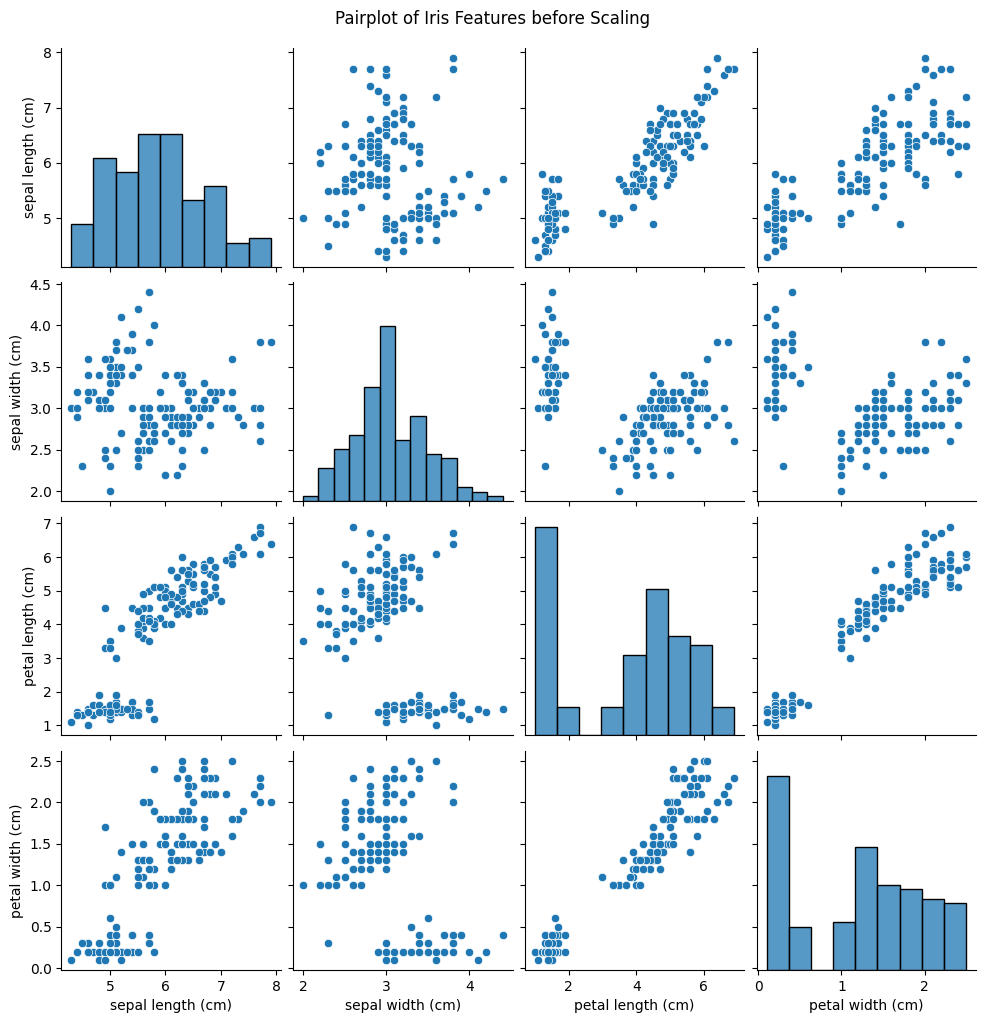

  K=2   |   0.57


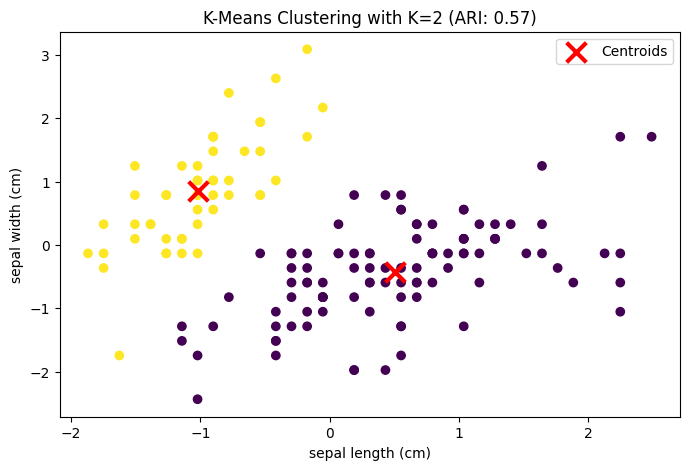

  K=3   |   0.62


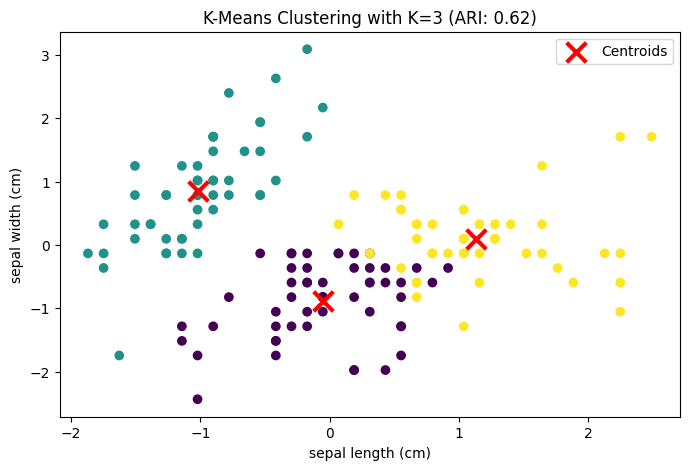

  K=4   |   0.47


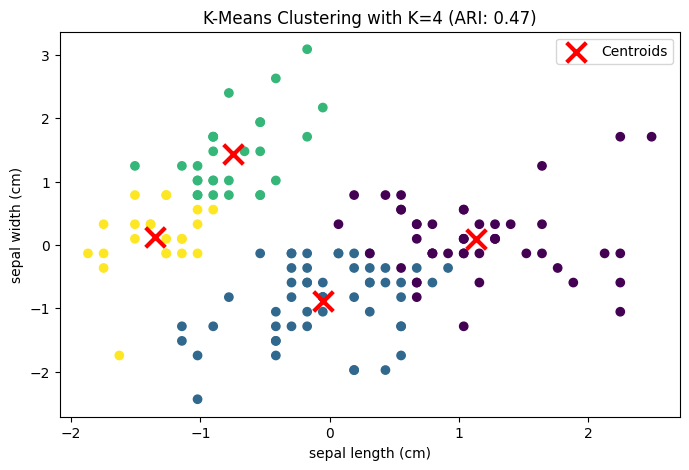

  K=5   |   0.43


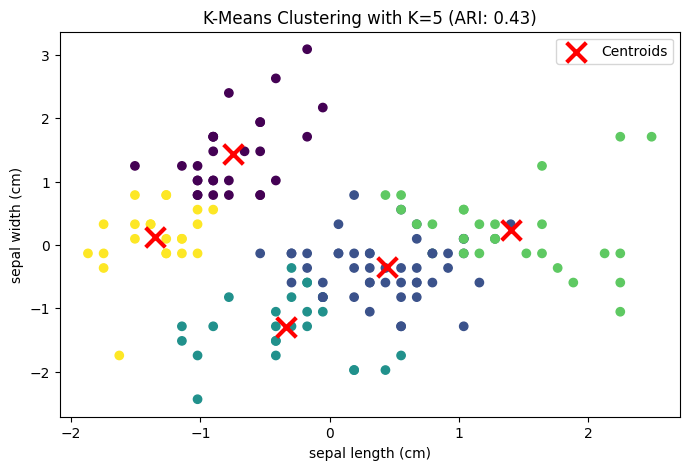

  K=6   |   0.45


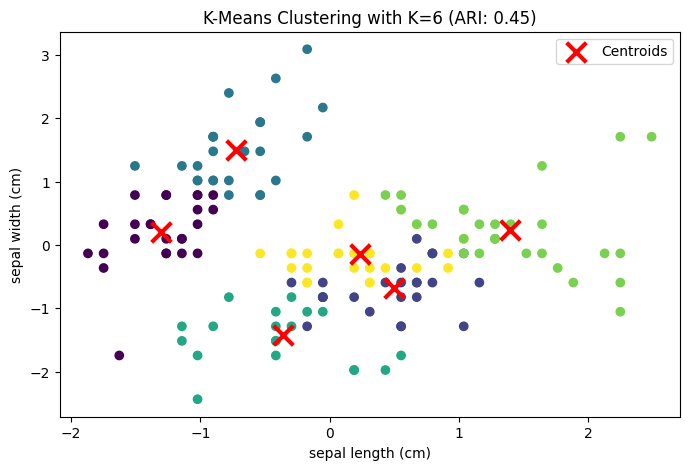

Cluster memberships:
[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1 -1  0  0  0  0  0  0  0 -1  0  0  0  0  0  0
  0  0  1  1  1  1  1  1 -1 -1  1 -1 -1  1 -1  1  1  1  1  1 -1  1  1  1
 -1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1  1  1  1  1 -1  1  1
  1  1 -1  1 -1  1  1  1  1 -1 -1 -1 -1 -1  1  1  1  1 -1  1  1 -1 -1 -1
  1  1 -1  1  1 -1  1  1  1 -1 -1 -1  1  1  1 -1 -1  1  1  1  1  1  1  1
  1  1  1  1 -1  1]


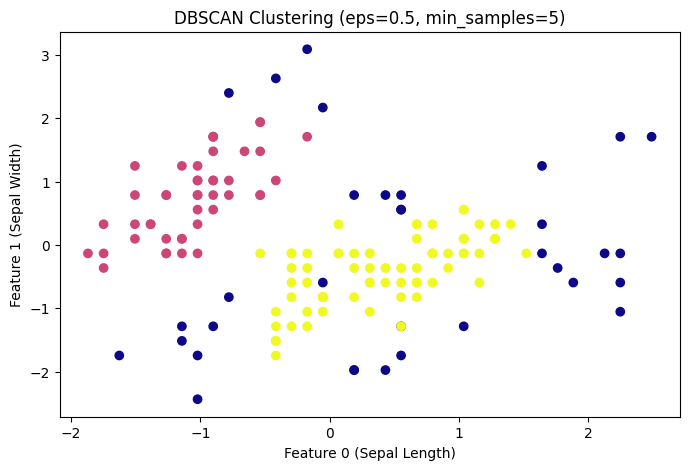

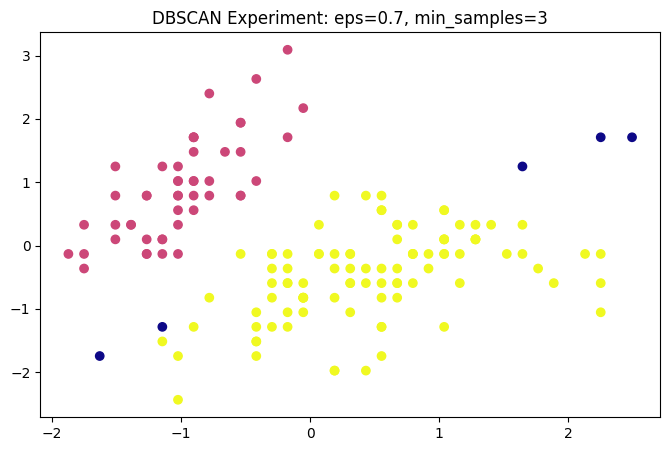

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, adjusted_rand_score
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

print(df.head())
print(df.describe())
sns.pairplot(df)
plt.suptitle("Pairplot of Iris Features before Scaling", y=1.02)
plt.show()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# User requested loop for K-Means
for k in [2, 3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    # Calculate the ARI score
    score = adjusted_rand_score(iris.target, labels)
    print(f"  K={k}   |   {score:.2f}")

    # --- Plotting each result (Added to your loop) ---
    plt.figure(figsize=(8, 5))
    # Using the first two features for a 2D plot (Sepal Length vs Sepal Width)
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='viridis')

    # Plotting the Centroids (Page 170 in Textbook)
    centroids = km.cluster_centers_
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='x', s=200,
                linewidths=3, color='red', label='Centroids')

    plt.title(f"K-Means Clustering with K={k} (ARI: {score:.2f})")
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])
    plt.legend()
    plt.show()

# --- DBSCAN Section ---
dbscan = DBSCAN(eps=0.5, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

print("Cluster memberships:\n{}".format(clusters))
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='plasma')
plt.xlabel("Feature 0 (Sepal Length)")
plt.ylabel("Feature 1 (Sepal Width)")
plt.title("DBSCAN Clustering (eps=0.5, min_samples=5)")
plt.show()

dbscan_2 = DBSCAN(eps=0.7, min_samples=3)
clusters_2 = dbscan_2.fit_predict(X_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters_2, cmap='plasma')
plt.title("DBSCAN Experiment: eps=0.7, min_samples=3")
plt.show()